In [11]:
params = {
    'legend.title_fontsize': 'large',
    'axes.labelsize': 16,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'text.usetex': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.top': True,
    'ytick.right': True,
    'figure.autolayout': True,
}
plt.rcParams.update(params)

woh_iso = pd.read_csv("data/wohletz_isothermal.csv")
woh_adi = pd.read_csv("data/wohletz_adiabatic.csv")


/var/folders/q2/2v_9qp1s1n9635tlzjm697gc0000gr/T/ipykernel_36252/3890805895.py:358: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig("wohletz_overlay_threshold.png", dpi=300, bbox_inches="tight")
/Users/carrile/anaconda3/envs/mohrfail/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


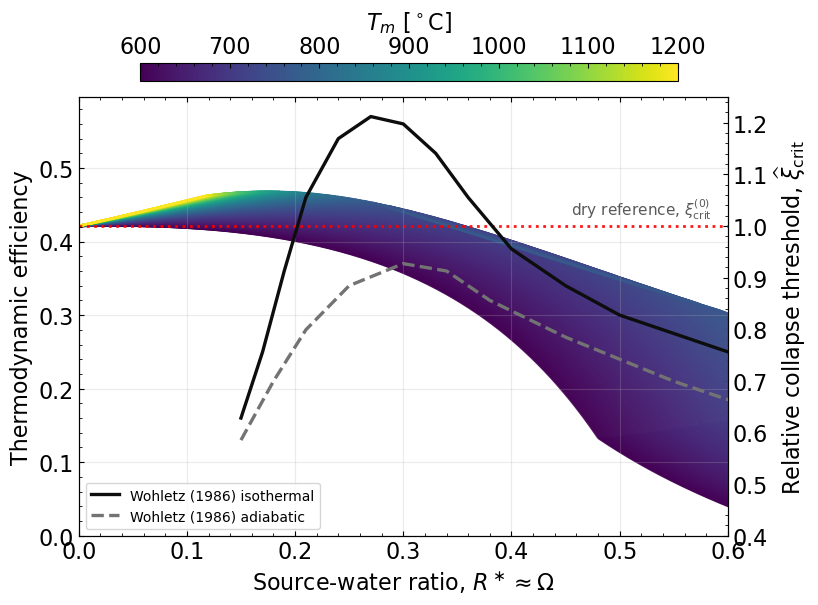

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Load digitized Wohletz curves
# ============================================================
# Expected files:
#   wohletz_fig2_isothermal_digitized.csv
#   wohletz_fig2_adiabatic_digitized.csv
#
# Expected columns:
#   Omega_or_Rstar, efficiency, curve
#
# In Wohletz, the x-axis is R* = m_water / m_magma.
# In the present model, this is compared with Omega = m_w / m_e.
# woh_iso = pd.read_csv("data/wohletz_isothermal.csv")
# woh_adi = pd.read_csv("data/wohletz_adiabatic.csv")

# Rename x column for cleaner plotting
woh_iso = woh_iso.rename(columns={"Omega_or_Rstar": "Rstar"})
woh_adi = woh_adi.rename(columns={"Omega_or_Rstar": "Rstar"})

# If the efficiency value is in percent, uncomment these:
# woh_iso["efficiency"] = woh_iso["efficiency"] / 100.0
# woh_adi["efficiency"] = woh_adi["efficiency"] / 100.0


# ============================================================
# 2. Analytical threshold model
# ============================================================

p = {
    "T_air": 273.15,
    "T_w0": 273.15,
    "T_sat": 373.15,
    "n": 0.03,
    "Cp_air": 1004.0,
    "Cp_m": 3000.0,
    "Cp_w": 1850.0,
    "Cp_l": 4180.0,
    "R_air": 287.0,
    "R_g": 461.5,
    "R_w": 461.5,
    "Lv": 2.5e6,
}

Tm_C_vals = np.linspace(600, 1200, 600)
Tm_vals = Tm_C_vals + 273.15
Omega_vals = np.linspace(1.0e-4, 0.60, 500)


def H_coeffs(Omega, Tm, p):
    H0 = p["Cp_air"] * (p["T_air"] - p["T_sat"])

    H1 = (
        p["Cp_m"] * (Tm - p["T_sat"])
        - (1.0 + Omega) * p["Cp_air"] * (p["T_air"] - p["T_sat"])
        + Omega * p["Cp_l"] * (p["T_w0"] - p["T_sat"])
    )

    return H0, H1


def H_i(xi, Omega, Tm, p):
    H0, H1 = H_coeffs(Omega, Tm, p)
    return H0 + H1 * xi


def xi_max(Omega):
    return 1.0 / (1.0 + Omega)


def safe_div(num, den):
    if abs(den) < 1.0e-14:
        return np.nan
    return num / den


def candidate_A(Omega, Tm, p):
    Rair = p["R_air"]
    Tair = p["T_air"]
    Cpa = p["Cp_air"]

    DeltaR_A = (1.0 + Omega) * p["R_air"] - p["n"] * p["R_g"]

    N_A1 = (
        p["Cp_m"] * Tm
        - (1.0 + Omega) * p["Cp_air"] * p["T_air"]
        + Omega * p["Cp_l"] * p["T_w0"]
    )

    D_A1 = (
        p["Cp_m"]
        - (1.0 + Omega) * p["Cp_air"]
        + Omega * p["Cp_l"]
    )

    a = -DeltaR_A * N_A1
    b = Rair * N_A1 - DeltaR_A * Cpa * Tair - Rair * Tair * D_A1

    return safe_div(-b, a)


def candidate_B(Omega, Tm, p):
    if Omega <= 0.0:
        return np.nan

    H0, H1 = H_coeffs(Omega, Tm, p)

    DeltaR_A = (1.0 + Omega) * p["R_air"] - p["n"] * p["R_g"]

    num = (
        p["R_air"] * (p["T_air"] - p["T_sat"])
        - (p["R_w"] / p["Lv"]) * H0 * p["T_sat"]
    )

    den = (
        -DeltaR_A
        + (p["R_w"] / p["Lv"]) * H1
    ) * p["T_sat"]

    return safe_div(num, den)


def candidate_C(Omega, Tm, p):
    Rair = p["R_air"]
    Tair = p["T_air"]
    Cpa = p["Cp_air"]

    H0, H1 = H_coeffs(Omega, Tm, p)

    DeltaR_C = (
        (1.0 + Omega) * p["R_air"]
        - p["n"] * p["R_g"]
        - Omega * p["R_w"]
    )

    D_C1 = (
        p["Cp_m"]
        - (1.0 + Omega) * p["Cp_air"]
        + Omega * p["Cp_w"]
    )

    S_C1 = p["T_sat"] * D_C1 + H1 - Omega * p["Lv"]

    a = -DeltaR_C * S_C1
    b = Rair * S_C1 - DeltaR_C * Cpa * Tair - Rair * Tair * D_C1

    return safe_div(-b, a)


def is_physical_xi(xi, Omega, tol=1.0e-10):
    return (
        np.isfinite(xi)
        and xi > tol
        and xi <= xi_max(Omega) + tol
    )


def admissible_candidates(Omega, Tm, p):
    out = []

    xiA = candidate_A(Omega, Tm, p)
    xiB = candidate_B(Omega, Tm, p)
    xiC = candidate_C(Omega, Tm, p)

    if is_physical_xi(xiA, Omega):
        H = H_i(xiA, Omega, Tm, p)
        if H <= 0.0:
            out.append(("A", xiA))

    if is_physical_xi(xiB, Omega):
        H = H_i(xiB, Omega, Tm, p)
        if 0.0 < H < Omega * xiB * p["Lv"]:
            out.append(("B", xiB))

    if is_physical_xi(xiC, Omega):
        H = H_i(xiC, Omega, Tm, p)
        if H >= Omega * xiC * p["Lv"]:
            out.append(("C", xiC))

    return out


def dry_reference_xi(Tm, p):
    return candidate_A(0.0, Tm, p)


def select_threshold_curve(Omega_vals, Tm, p):
    xi_sel = np.full_like(Omega_vals, np.nan, dtype=float)
    reg_sel = np.full(Omega_vals.shape, "", dtype=object)

    xi_ref = dry_reference_xi(Tm, p)

    for i, Omega in enumerate(Omega_vals):
        candidates = admissible_candidates(Omega, Tm, p)

        if len(candidates) == 0:
            continue

        regimes = [c[0] for c in candidates]
        xis = np.array([c[1] for c in candidates])

        j = np.nanargmin(np.abs(xis - xi_ref))

        reg_sel[i] = regimes[j]
        xi_sel[i] = xis[j]
        xi_ref = xi_sel[i]

    return xi_sel, reg_sel


# ============================================================
# 3. Compute normalized collapse threshold
# ============================================================

results = {}

for Tm_C, Tm in zip(Tm_C_vals, Tm_vals):
    xi_curve, reg_curve = select_threshold_curve(Omega_vals, Tm, p)
    xi_dry = dry_reference_xi(Tm, p)

    xi_hat = xi_curve / xi_dry

    results[Tm_C] = {
        "Omega": Omega_vals,
        "xi": xi_curve,
        "xi_hat": xi_hat,
        "regime": reg_curve,
        "xi_dry": xi_dry,
    }

# ============================================================
# 4. Single-panel comparison plot with two y-axes
# ============================================================

import matplotlib as mpl
from matplotlib.lines import Line2D

fig, ax_eff = plt.subplots(figsize=(8.4, 5.4))

# ------------------------------------------------------------
# Left y-axis: Wohletz thermodynamic efficiency
# ------------------------------------------------------------

line_iso, = ax_eff.plot(
    woh_iso["Rstar"],
    woh_iso["efficiency"],
    color="0.05",
    linewidth=2.4,
    label="Wohletz (1986) isothermal",
    zorder = 20
)

line_adi, = ax_eff.plot(
    woh_adi["Rstar"],
    woh_adi["efficiency"],
    color="0.45",
    linewidth=2.4,
    linestyle="--",
    label="Wohletz (1986) adiabatic",
    zorder = 19,
)

ax_eff.set_ylabel("Thermodynamic efficiency")
ax_eff.set_xlim(0.0, 0.60)
ax_eff.set_ylim(bottom=0.0)
ax_eff.grid(True, alpha=0.25)

# ------------------------------------------------------------
# Right y-axis: present normalized collapse threshold
# ------------------------------------------------------------

ax_thr = ax_eff.twinx()

# Put Wohletz axis above threshold axis
ax_eff.set_zorder(3)
ax_thr.set_zorder(2)

# Make the upper axis background transparent so it does not hide the other data
ax_eff.patch.set_visible(False)

norm = mpl.colors.Normalize(vmin=Tm_C_vals.min(), vmax=Tm_C_vals.max())
cmap = plt.cm.viridis
colors = cmap(norm(Tm_C_vals))

for color, Tm_C in zip(colors, Tm_C_vals):
    Omega = results[Tm_C]["Omega"]
    xi_hat = results[Tm_C]["xi_hat"]

    valid = np.isfinite(xi_hat)

    ax_thr.plot(
        Omega[valid],
        xi_hat[valid],
        color=color,
        linewidth=1.6,
        alpha=0.9
    )

ax_thr.axhline(
    1.0,
    color="red",
    linewidth=2.0,
    linestyle=":",
    alpha=0.9
)

ax_thr.set_ylabel(r"Relative collapse threshold, $\widehat{\xi}_{\rm crit}$")

# Set this based on your curve range
ax_thr.set_ylim(0.4, 1.25)

# ------------------------------------------------------------
# Shared x-axis
# ------------------------------------------------------------

ax_eff.set_xlabel(r"Source-water ratio, $R^\ast \approx \Omega$")
# Wohletz legend
ax_eff.legend(
    handles=[line_iso, line_adi],
    loc="lower left",
    frameon=True,
    fontsize=10
)

# Temperature colorbar for present-model curves, manually placed above plot
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.subplots_adjust(top=0.84)

cax = fig.add_axes([0.18, 0.99, 0.64, 0.035])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label(r"$T_m$ [$^\circ$C]", labelpad=4)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")

# Annotation for dry reference
ax_thr.text(
    0.585,
    1.01,
    r"dry reference, $\xi_{\mathrm{crit}}^{(0)}$",
    ha="right",
    va="bottom",
    fontsize=11,
    color="0.35"
)

fig.savefig("wohletz_overlay_threshold.png", dpi=300, bbox_inches="tight")
plt.show()